In [1]:
import torch
from torch import nn
import pandas as pd
import sys
from pathlib import Path

train_labels = pd.read_csv('../cifar-10/trainLabels.csv')
val_labels = pd.read_csv('../cifar-10/valLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset, train_transforms, val_transforms

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=train_labels,
    transform=train_transforms
)

val_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/val',
    labels=val_labels,
    transform=val_transforms
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
from src.models import CIFARBatchNorm
from src.metrics import create_metrics
from src.engine import fit

model = CIFARBatchNorm().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
epochs = 30

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Augmentation_WD_FeatureCNN_BatchNorm.pt'
)

history


Epoch 1/30:
Training Loss: 1.4328 | Training Accuracy: 47.47% | Training Precision: 46.75% | Training Recall: 47.47%
Validation Loss: 1.1231 | Validation Accuracy: 59.82% | Validation Precision: 64.41% | Validation Recall: 59.82%
Best model saved! Val Acc: 59.82%

Epoch 2/30:
Training Loss: 1.0003 | Training Accuracy: 64.31% | Training Precision: 63.99% | Training Recall: 64.31%
Validation Loss: 0.9230 | Validation Accuracy: 66.68% | Validation Precision: 71.28% | Validation Recall: 66.68%
Best model saved! Val Acc: 66.68%

Epoch 3/30:
Training Loss: 0.8363 | Training Accuracy: 70.44% | Training Precision: 70.25% | Training Recall: 70.44%
Validation Loss: 0.7601 | Validation Accuracy: 72.98% | Validation Precision: 73.32% | Validation Recall: 72.98%
Best model saved! Val Acc: 72.98%

Epoch 4/30:
Training Loss: 0.7422 | Training Accuracy: 73.87% | Training Precision: 73.74% | Training Recall: 73.87%
Validation Loss: 0.6575 | Validation Accuracy: 76.66% | Validation Precision: 76.80% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.432772,0.474725,0.467453,0.474725,1.123118,0.5982,0.644067,0.5982
1,2,1.000295,0.643075,0.639862,0.643075,0.922980,0.6668,0.712846,0.6668
2,3,0.836321,0.704400,0.702493,0.704400,0.760146,0.7298,0.733198,0.7298
3,4,0.742157,0.738700,0.737381,0.738700,0.657501,0.7666,0.768034,0.7666
4,5,0.670042,0.764975,0.764165,0.764975,0.673373,0.7692,0.785463,0.7692
5,6,0.616519,0.783200,0.782588,0.783200,0.623383,0.7874,0.795512,0.7874
6,7,0.568889,0.802100,0.801509,0.802100,0.517232,0.8274,0.831882,0.8274
7,8,0.531279,0.816375,0.815802,0.816375,0.508696,0.8228,0.827129,0.8228
8,9,0.504587,0.826425,0.825973,0.826425,0.511942,0.8346,0.837576,0.8346
9,10,0.467653,0.837775,0.837565,0.837775,0.481391,0.8388,0.846152,0.8388


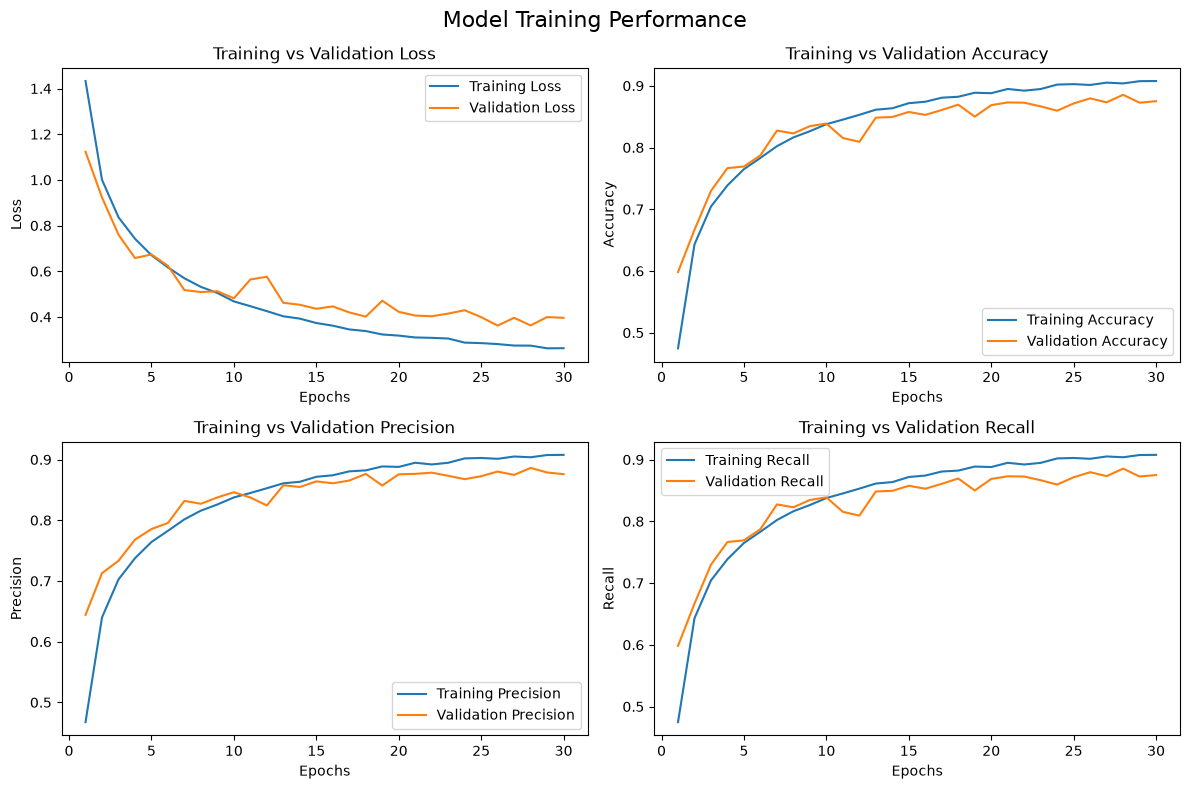

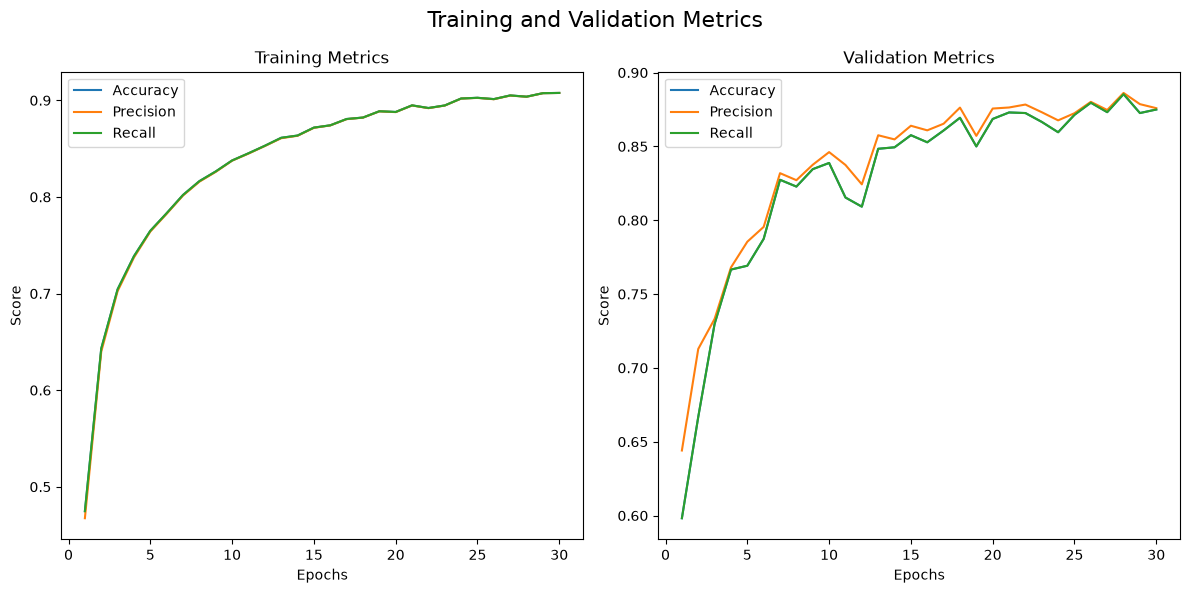

In [6]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)